In [187]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
import time

def train_classification_models(X_train, X_test, y_train, y_test, sort_by="Accuracy", lr=True, rf=True, sgd=True, mlp=True, mlp_solver="adam", knc=True):
    models = {}
    if lr:
        models["Logistic Regression"] = LogisticRegression(max_iter=1000, random_state=42)
    if rf:
        models["Random Forest"] = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1, criterion="entropy")
    if sgd:
        models["Gradient Descent"] = SGDClassifier(max_iter=1000, random_state=42, loss="log_loss")
    if mlp:
        models["Multi-layer Perceptron"] = MLPClassifier(max_iter=1000, solver=mlp_solver, alpha=1e-5, hidden_layer_sizes=(5, 2), random_state=42)
    if knc:
        models["KNN"] = KNeighborsClassifier(n_neighbors=5)

    metrics_report = []
    
    for model_name, model in models.items():
        start_time = time.time()
        
        model.fit(X_train, y_train)
        
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]
        
        train_time = time.time() - start_time
        
        metrics_report.append({
            "Model": model_name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision (CT)": precision_score(y_test, y_pred),
            "Recall (CT)": recall_score(y_test, y_pred),
            "F1 Score": f1_score(y_test, y_pred),
            "ROC AUC": roc_auc_score(y_test, y_prob),
            "Time (sec)": round(train_time, 2)
        })
    
    report_df = pd.DataFrame(metrics_report)
    report_df = report_df.sort_values(by=sort_by, ascending=False).reset_index(drop=True)
    print(report_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
    return models

def visualize_feature_importance(model, X, positive_threshold=0.1, negative_threshold=-0.1, model_type="Logistic Regression"):
    if model_type == "Logistic Regression":
        importances = pd.DataFrame({
            'Feature': X,
            'Importance': model.coef_[0]
        })
        
    elif model_type == "Random Forest":
        importances = pd.DataFrame({
            'Feature': X,
            'Importance': model.feature_importances_
        })
        
    importances = importances.sort_values(by='Importance', ascending=False)
    importances_pos = importances[(importances['Importance'] > positive_threshold) & (importances['Importance'] > 0)]
    if model_type == "Logistic Regression":
        importances_neg = importances[(importances['Importance'] < negative_threshold) & (importances['Importance'] < 0)]
        importances = pd.concat([importances_pos, importances_neg], axis=0)
    else:
        importances = importances_pos
    
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.barplot(data=importances, x='Importance', y='Feature', ax=ax, palette='mako', hue="Feature")
    
    ax.set_title(f"Feature importance {model_type}")
    ax.set_xlabel("Weight")
    ax.set_ylabel("Feature")
    ax.grid(axis='x', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()
    
    print(importances.to_string(index=False))

In [188]:
splits = {'train': 'train.csv', 'validation': 'valid.csv', 'test': 'test.csv'}
df = pd.read_csv("hf://datasets/AI4Protein/eSOL/" + splits["train"])
val_df = pd.read_csv("hf://datasets/AI4Protein/eSOL/" + splits["validation"])
test_df = pd.read_csv("hf://datasets/AI4Protein/eSOL/" + splits["test"])
df = pd.concat([df, val_df, test_df], axis=0)
df.head(10)

,name,aa_seq,gene,label
0,P0ABL8,MMFWRIFRLELRVAFRHSAEIANPLWFFLIVITLFPLSIGPEPQLLARIAPGIIWVAALLSSLLALERLFRDDLQDGSLEQLMLLPLPLPAVVLAKVMAHWMVTGLPLLILSPLVAMLLGMDVYGWQVMALTLLLGTPTLGFLGAPGVALTVGLKRGGVLLSILVLPLTIPLLIFATAAMDAASMHLPVDGYLAILGALLAGTATLSPFATAAALRISIQ,ccmB,0.04
1,P77721,MAAKDRIQAIKQMVANDKKVTVSNLSGIFQVTEETIRRDLEKLEDEGFLTRTYGGAVLNTAMLTENIHFYKRASSFYEEKQLIARKALPFIDNKTTMAADSSSTVMELLKLLQDRSGLTLLTNSAEAIHVLAQSEIKVVSTGGELNKNTLSLQGRITKEIIRRYHVDIMVMSCKGLDINSGALDSNEAEAEIKKTMIRQATEVALLVDHSKFDRKAFVQLADFSHINYIITDKSPGAEWIAFCKDNNIQLVW,ydjF,0.04
2,Q47152,MSEYRRYYIKGGTWFFTVNLRNRRSQLLTTQYQMLRHAIIKVKRDRPFEINAWVVLPEHMHCIWTLPEGDDDFSSRWREIKKQFTHACGLKNIWQPRFWEHAIRNTKDYRHHVDYIYINPVKHGWVKQVSDWPFSTFHRDVARGLYPIDWAGDVTDFSAGERIIS,yafM,0.47
3,P30958,MPEQYRYTLPVKAGEQRLLGELTGAACATLVAEIAERHAGPVVLIAPDMQNALRLHDEISQFTDQMVMNLADWETLPYDSFSPHQDIISSRLSTLYQLPTMQRGVLIVPVNTLMQRVCPHSFLHGHALVMKKGQRLSRDALRTQLDSAGYRHVDQVMEHGEYATRGALLDLFPMGSELPYRLDFFDDEIDSLRVFDVDSQRTLEEVEAINLLPAHEFPTDKAAIELFRSQWRDTFEVKRDPEHIYQQVSKGTLPAGIEYWQPLFFSEPLPPLFSYFPANTLLVNTGDLETSAERFQADTLARFENRGVDPMRPLLPPQSLWLRVDELFSELKNWPRVQLKTEHLPTKAANANLGFQKLPDLAVQAQQKAPLDALRKFLETFDGPVVFSVESEGRREALGELLARIKIAPQRIMRLDEASDRGRYLMIGAAEHGFVDTVRNLALICESDLLGERVARRRQDSRRTINPDTLIRNLAELHIGQPVVHLEHGVGRYAGMTTLEAGGITGEYLMLTYANDAKLYVPVSSLHLISRYAGGAEENAPLHKLGGDAWSRARQKAAEKVRDVAAELLDIYAQRAAKEGFAFKHDREQYQLFCDSFPFETTPDQAQAINAVLSDMCQPLAMDRLVCGDVGFGKTEVAMRAAFLAVDNHKQVAVLVPTTLLAQQHYDNFRDRFANWPVRIEMISRFRSAKEQTQILAEVAEGKIDILIGTHKLLQSDVKFKDLGLLIVDEEHRFGVRHKERIKAMRANVDILTLTATPIPRTLNMAMSGMRDLSIIATPPARRLAVKTFVREYDSMVVREAILREILRGGQVYYLYNDVENIQKAAERLAELVPEARIAIGHGQMRERELERVMNDFHHQRFNVLVCTTIIETGIDIPTANTIIIERADHFGLAQLHQLRGRVGRSHHQAYAWLLTPHPKAMTTDAQKRLEAIASLEDLGAGFALATHDLEIRGAGELLGEEQSGSMETIGFSLYMELLENAVDALKAGREPSLEDLTSQQTEVELRMPSLLPDDFIPDVNTRLSFYKRIASAKTENELEEIKVELIDRFGLLPDPARTLLDIARLRQQAQKLGIRKLEGNEKGGVIEFAEKNHVNPAWLIGLLQKQPQHYRLDGPTRLKFIQDLSERKTRIEWVRQFMRELEENAIA,mfd,0.67
4,P0C8J8,MKTLIARHKAGEHIGICSVCSAHPLVIEAALAFDRNSTRKVLIEATSNQVNQFGGYTGMTPADFREFVFTIADKVGFARERIILGGDHLGPNCWQQENADAAMEKSVELVKEYVRAGFSKIHLDASMSCAGDPIPLAPETVAERAAVLCFAAESVATDCQREQLSYVIGTEVPVPGGEASAIQSVHITHVEDAANTLRTHQKAFIARGLTEALTRVIAIVVQPGVEFDHSNIIHYQPQEAQPLAQWIENTRMVYEAHSTDYQTRTAYWELVRDHFAILKVGPALTFALREAIFALAQIEQELIAPENRSGCLAVIEEVMLDEPQYWKKYYRTGFNDSLLDIRYSLSDRIRYYWPHSRIKNSVETMMVNLEGVDIPLGMISQYLPKQFERIQSGELSAIPHQLIMDKIYDVLRAYRYGCAE,gatZ,0.07
5,P39829,MANIEIRQETPTAFYIKVHDTDNVAIIVNDNGLKAGTRFPDGLELIEHIPQGHKVALLDIPANGEIIRYGEVIGYAVRAIPRGSWIDESMVVLPEAPPLHTLPLATKVPEPLPPLEGYTFEGYRNADGSVGTKNLLGITTSVHCVAGVVDYVVKIIERDLLPKYPNVDGVVGLNHLYGCGVAINAPAAVVPIRTIHNISLNPNFGGEVMVIGLGCEKLQPERLLTGTDDVQAIPVESASIVSLQDEKHVGFQSMVEDILQIAERHLQKLNQRQRETCPASELVVGMQCGGSDAFSGVTANPAVGYASDLLVRCGATVMFSEVTEVRDAIHLLTPRAVNEEVGKRLLEEMEWYDNYLNMGKTDRSANPSPGNKKGGLANVVEKALGSIAKSGKSAIVEVLSPGQRPTKRGLIYAATPASDFVCGTQQVASGITVQVFTTGRGTPYGLMAVPVIKMATRTELANRWFDLMDINAGTIATGEETIEEVGWKLFHFILDVASGKKKTFSDQWGLHNQLAVFNPAPVT,garD,0.48
6,P52045,MSYQYVNVVTINKVAVIEFNYGRKLNALSKVFIDDLMQALSDLNRPEIRCIILRAPSGSKVFSAGHDIHELPSGGRDPLSYDDPLRQITRMIQKFPKPIISMVEGSVWGGAFEMIMSSDLIIAASTSTFSMTPVNLGVPYNLVGIHNLTRDAGFHIVKELIFTASPITAQRALAVGILNHVVEVEELEDFTLQMAHHISEKAPLAIAVIKEELRVLGEAHTMNSDEFERIQGMRRAVYDSEDYQEGMNAFLEKRKPNFVGH,ygfG,0.56
7,P25889,MLTKDLSITFCGVKFPNPFCLSSSPVGNCYEMCAKAYDTGWGGVVFKTIGFFIANEVSPRFDHLVKEDTGFIGFKNMEQIAEHPLEENLAALRRLKEDYPDKVLIASIMGENEQQWEELARLVQEAGADMIECNFSCPQMTSHAMGSDVGQSPELVEKYCRAVKRGSTLPMLAKMTPNIGDMCEVALAAKRGGADGIAAINTVKSITNIDLNQKIGMPIVNGKSSISGYSGKAVKPIALRFIQQMRTHPELRDFPISGIGGIETWEDAAEFLLLGAATLQVTTGIMQYGYRIVEDMASGLSHYLADQGFDSLQEMVGLANNNIVPAEDLDRSYIVYPRINLDKCVGCGRCYISCYDGGHQAMEWSEKTRTPHCNTEKCVGCLLCGHVCPVGCIELGEVKFKKGEKEHPVTL,yeiA,0.65
8,P0A786,MANPLYQKHIISINDLSRDDLNLVLATAAKLKANPQPELLKHKVIASCFFEASTRTRLSFETSMHRLGASVVGFSDSANTSLGKKGETLADTISVISTYVDAIVMRHPQEGAARLATEFSGNVPVLNAGDGSNQHPTQTLLDLFTIQETQGRLDNLHVAMVGDLKYGRTVHSLTQALAKFDGNRFYFIAPDALAMPQYILDMLDEKGIAWSLHSSIEEVMAEVDILYMTRVQKERLDPSEYANVKAQFVLRASDLHNAKANMKVLHPLPRVDEIATDVDKTPHAWYFQQAGNGIFARQALLALVLNRDLVL,pyrB,0.79
9,P33360,MIEFSHVSKLFGAQKAVNDLNLNFQEGSFSVLIGTSGSGKSTTLKMINRLVEHDSGEIRFAGEEIRSLPVLELRRRM

In [189]:
df["label"].median()

np.float64(0.43)

In [190]:
df.loc[df["label"] >= 0.43, "label"] = 1
df.loc[df["label"] <= 0.43, "label"] = 0
df["label"].value_counts(normalize=True)

label
1.0    0.500161
0.0    0.499839
Name: proportion, dtype: float64

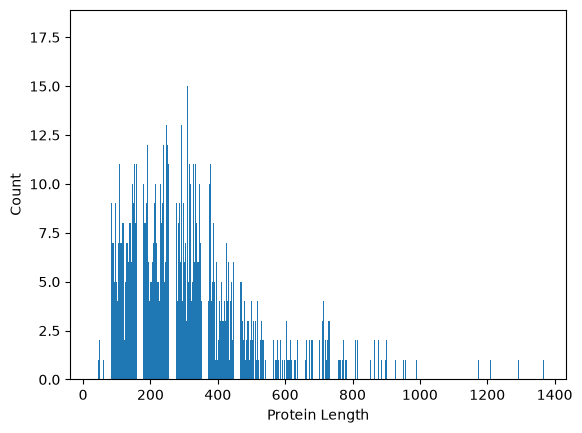

In [191]:
length_distribution = df["aa_seq"].str.len().value_counts()
fig, ax = plt.subplots()
ax.bar(length_distribution.index, length_distribution.values)
plt.xlabel("Protein Length")
plt.ylabel("Count")
plt.show()

In [192]:
length_distribution

aa_seq
231    18
310    15
196    15
220    13
292    13
       ..
853     1
716     1
661     1
496     1
834     1
Name: count, Length: 709, dtype: int64

In [193]:
df["aa_seq"].str.len().median()

np.float64(275.0)

In [194]:
chars = set()
for seq in df["aa_seq"]:
    chars |= set(seq)
chars

{'A',
 'C',
 'D',
 'E',
 'F',
 'G',
 'H',
 'I',
 'K',
 'L',
 'M',
 'N',
 'P',
 'Q',
 'R',
 'S',
 'T',
 'V',
 'W',
 'Y'}

### A)One-Hot-Encoder

In [195]:
def one_hot_encode(sequences: pd.Series, length=200, flatten_output=False):
    alphabet = {char: idx for idx, char in enumerate('ACDEFGHIKLMNPQRSTVWY')}
    
    seqs = sequences.astype(str).str.slice(0, length).tolist()

    tensor = np.zeros((len(seqs), length, 20), dtype=np.int8)
    
    for i, seq in enumerate(seqs):
        for j, char in enumerate(seq):
            if char in alphabet:
                tensor[i, j, alphabet[char]] = 1
                
    if flatten_output:
        return tensor.reshape(len(seqs), -1)
    
    return tensor

print(f"3D shape: {one_hot_encode(df["aa_seq"]).shape}")
print(f"Flattened shape: {one_hot_encode(df["aa_seq"], flatten_output=True).shape}")

3D shape: (3101, 200, 20)
Flattened shape: (3101, 4000)


### B)K-mer Counter

In [196]:
import itertools
def kmer_counter(sequences: pd.Series, k=3):
    alphabet = ['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y']
    kmers = itertools.product(alphabet, repeat=k)
    kmers = {"".join(kmer): idx for idx, kmer in enumerate(kmers)}
    tensor = np.zeros((len(sequences), len(kmers)), dtype=np.int32)
    for i, seq in enumerate(sequences):
        for j, char in enumerate(seq):
            if j+k > len(seq):
                break
            kmer = seq[j:j + k]
            tensor[i, kmers[kmer]] += 1            
    return tensor, kmers.keys()
print(f"k=2 shape: {kmer_counter(df["aa_seq"], k=2)[0].shape}")
print(f"k=3 shape: {kmer_counter(df["aa_seq"])[0].shape}")

k=2 shape: (3101, 400)
k=3 shape: (3101, 8000)


### C)Physicochemical Extractor

In [203]:
from Bio.SeqUtils.ProtParam import ProteinAnalysis

def extract_physicochemical_features(sequences: pd.Series, 
            aa_counts=False, aa_percents=True, molecular_weight=True, aromaticity=False, instability_index=True, 
            flexibility=True, gravy=True, isoelectric_point=True, charge_at_pH=True, pH=7, secondary_structure_fraction=True):
    
    alphabet = ['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y']
    
    features_list = []
        
    for seq in sequences:
        prt = ProteinAnalysis(seq)
        
        row_data = {}
        
        if aa_counts:
            counts = prt.count_amino_acids()
            for char in alphabet:
                row_data[f"{char}_count"] = counts.get(char, 0)
                
        if aa_percents:
            percents = prt.amino_acids_percent
            for char in alphabet:
                row_data[f"{char}_percent"] = percents.get(char, 0.0)
                
        if molecular_weight:
            row_data["molecular_weight_per_length"] = prt.molecular_weight()
        if aromaticity:
            row_data["aromaticity"] = prt.aromaticity()
        if instability_index:
            row_data["instability_index"] = prt.instability_index()
        if flexibility:
            flex = prt.flexibility()
            row_data["flexibility_mean"] = np.mean(flex) 
            row_data["flexibility_max"] = np.max(flex)
            row_data["flexibility_std"] = np.std(flex)
        if gravy:
            row_data["gravy"] = prt.gravy()
        if isoelectric_point:
            row_data["isoelectric_point"] = prt.isoelectric_point()
        if charge_at_pH:
            row_data["charge_at_pH"] = prt.charge_at_pH(pH)
        if secondary_structure_fraction:
            helix, turn, sheet = prt.secondary_structure_fraction()
            row_data["secondary_structure_fraction_helix"] = helix
            row_data["secondary_structure_fraction_turn"] = turn
            row_data["secondary_structure_fraction_sheet"] = sheet
                        
        features_list.append(row_data)
            
    return pd.DataFrame(features_list)
extract_physicochemical_features(df["aa_seq"]).shape

(3101, 31)

### Training models on those 3(4) feature sets

In [198]:
X = one_hot_encode(df["aa_seq"], flatten_output=True, length=310)
y = df["label"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
one_hot_models = train_classification_models(X_train, X_test, y_train, y_test, mlp_solver="lbfgs")

                 Model  Accuracy  Precision (CT)  Recall (CT)  F1 Score  ROC AUC  Time (sec)
Multi-layer Perceptron    0.6602          0.7094       0.5372    0.6114   0.6593      2.8000
   Logistic Regression    0.6377          0.6304       0.6570    0.6434   0.6844      0.4500
         Random Forest    0.6361          0.6895       0.4887    0.5720   0.7218      4.2700
      Gradient Descent    0.6232          0.6190       0.6311    0.6250   0.6551      1.9900
                   KNN    0.5201          0.5247       0.3786    0.4398   0.5209      0.3200


                 Model  Accuracy  Precision (CT)  Recall (CT)  F1 Score  ROC AUC  Time (sec)
   Logistic Regression    0.7118          0.6958       0.7476    0.7207   0.7678      0.5900
Multi-layer Perceptron    0.6876          0.6949       0.6634    0.6788   0.7343      3.2900
      Gradient Descent    0.6828          0.6728       0.7055    0.6888   0.7564      3.4700
         Random Forest    0.6812          0.7126       0.6019    0.6526   0.7567      4.7600
                   KNN    0.4799          0.4539       0.2233    0.2993   0.4830      0.4000


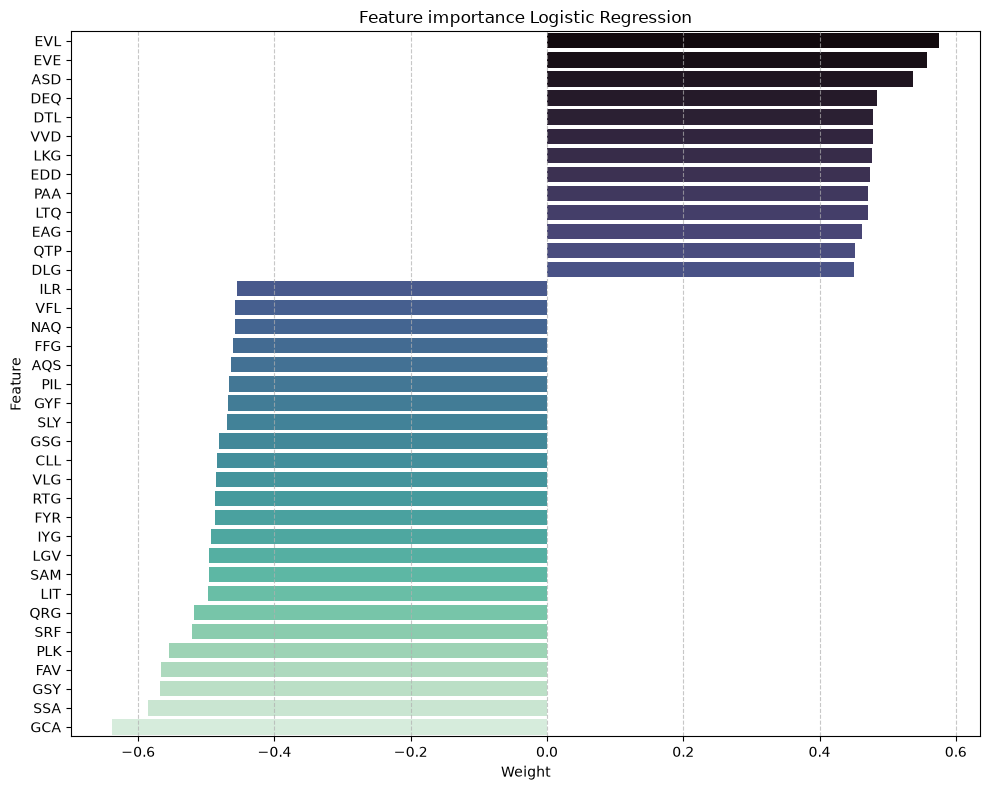

Feature  Importance
    EVL    0.574884
    EVE    0.557487
    ASD    0.536729
    DEQ    0.484592
    DTL    0.478550
    VVD    0.478186
    LKG    0.476821
    EDD    0.473521
    PAA    0.471652
    LTQ    0.470712
    EAG    0.462951
    QTP    0.451938
    DLG    0.450728
    ILR   -0.455084
    VFL   -0.457535
    NAQ   -0.457827
    FFG   -0.460906
    AQS   -0.463341
    PIL   -0.466309
    GYF   -0.468529
    SLY   -0.470149
    GSG   -0.481789
    CLL   -0.483984
    VLG   -0.485469
    RTG   -0.487007
    FYR   -0.487464
    IYG   -0.492914
    LGV   -0.495482
    SAM   -0.496702
    LIT   -0.497488
    QRG   -0.518366
    SRF   -0.521525
    PLK   -0.555030
    FAV   -0.565979
    GSY   -0.567829
    SSA   -0.585118
    GCA   -0.637678


In [199]:
X, kmers = kmer_counter(df["aa_seq"], 3)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
kmer_three_models = train_classification_models(X_train, X_test, y_train, y_test, mlp_solver="lbfgs")
visualize_feature_importance(kmer_three_models["Logistic Regression"], kmers, positive_threshold=0.45, negative_threshold=-0.45)

                 Model  Accuracy  Precision (CT)  Recall (CT)  F1 Score  ROC AUC  Time (sec)
   Logistic Regression    0.7101          0.7157       0.6926    0.7039   0.7784      0.1200
         Random Forest    0.6844          0.7132       0.6117    0.6585   0.7730      1.2500
Multi-layer Perceptron    0.6602          0.6644       0.6408    0.6524   0.7113      1.9300
                   KNN    0.6425          0.6205       0.7249    0.6687   0.6891      0.0500
      Gradient Descent    0.6280          0.5899       0.8285    0.6891   0.7171      0.2400


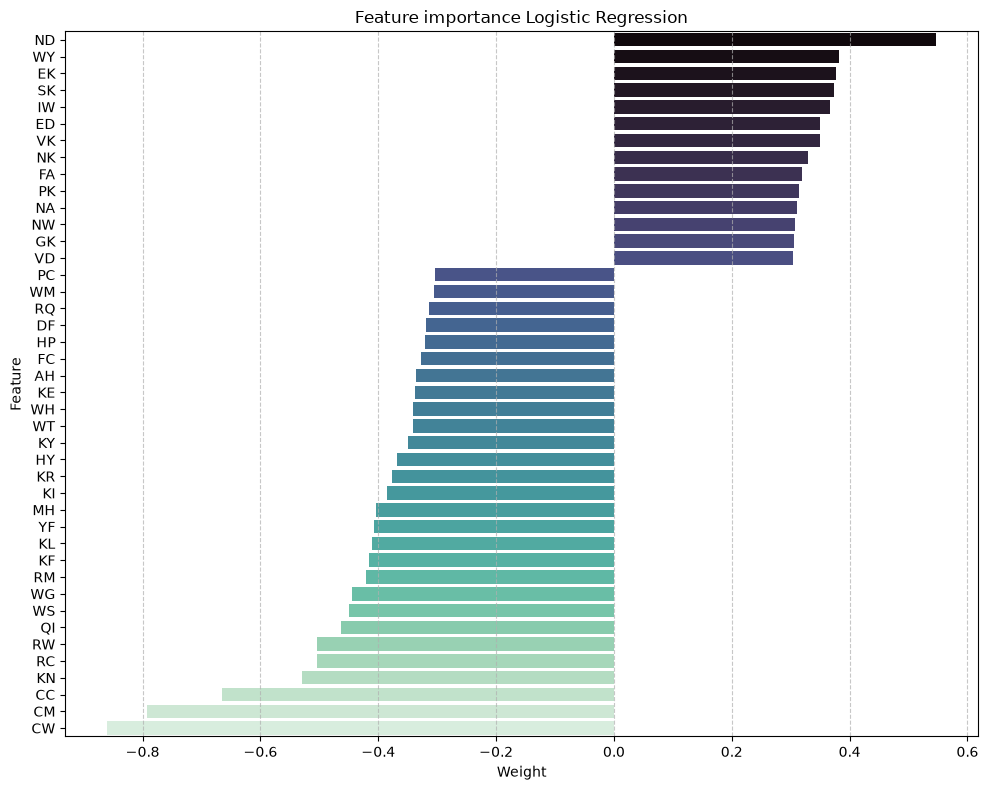

Feature  Importance
     ND    0.547140
     WY    0.382175
     EK    0.377051
     SK    0.373683
     IW    0.366511
     ED    0.349541
     VK    0.349076
     NK    0.329058
     FA    0.319182
     PK    0.313769
     NA    0.311283
     NW    0.307995
     GK    0.305097
     VD    0.303641
     PC   -0.303752
     WM   -0.305542
     RQ   -0.313296
     DF   -0.318888
     HP   -0.320370
     FC   -0.326917
     AH   -0.336633
     KE   -0.338419
     WH   -0.340805
     WT   -0.341076
     KY   -0.348767
     HY   -0.367734
     KR   -0.376892
     KI   -0.384803
     MH   -0.404089
     YF   -0.407073
     KL   -0.410620
     KF   -0.415158
     RM   -0.420919
     WG   -0.443743
     WS   -0.449336
     QI   -0.462600
     RW   -0.503590
     RC   -0.504742
     KN   -0.529748
     CC   -0.665374
     CM   -0.792957
     CW   -0.860955


In [200]:
X, kmers = kmer_counter(df["aa_seq"], 2)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
kmer_two_models = train_classification_models(X_train, X_test, y_train, y_test)
visualize_feature_importance(kmer_two_models["Logistic Regression"], kmers, positive_threshold=0.3, negative_threshold=-0.3)

                 Model  Accuracy  Precision (CT)  Recall (CT)  F1 Score  ROC AUC  Time (sec)
         Random Forest    0.7762          0.7931       0.7443    0.7679   0.8414      1.4400
   Logistic Regression    0.7697          0.7842       0.7411    0.7621   0.8271      0.0200
Multi-layer Perceptron    0.7424          0.7560       0.7120    0.7333   0.8139      2.8800
      Gradient Descent    0.7391          0.7653       0.6861    0.7235   0.8246      0.0300
                   KNN    0.7005          0.7552       0.5890    0.6618   0.7577      0.0100


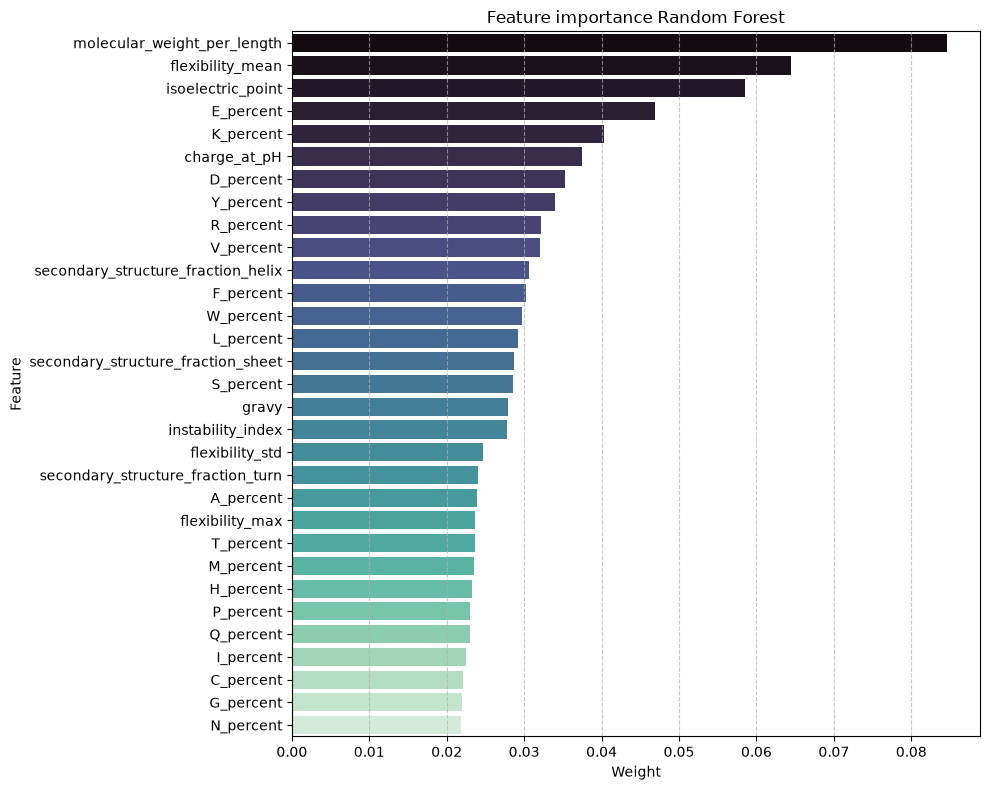

                           Feature  Importance
       molecular_weight_per_length    0.084637
                  flexibility_mean    0.064478
                 isoelectric_point    0.058491
                         E_percent    0.046912
                         K_percent    0.040297
                      charge_at_pH    0.037528
                         D_percent    0.035328
                         Y_percent    0.033973
                         R_percent    0.032173
                         V_percent    0.032038
secondary_structure_fraction_helix    0.030570
                         F_percent    0.030270
                         W_percent    0.029774
                         L_percent    0.029243
secondary_structure_fraction_sheet    0.028747
                         S_percent    0.028586
                             gravy    0.027903
                 instability_index    0.027781
                   flexibility_std    0.024700
 secondary_structure_fraction_turn    0.024033
             

In [201]:
from sklearn.preprocessing import StandardScaler
X = extract_physicochemical_features(df["aa_seq"])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
std_scaler = StandardScaler()
X_train = std_scaler.fit_transform(X_train)
X_test = std_scaler.transform(X_test)
physicochemical_models = train_classification_models(X_train, X_test, y_train, y_test)
visualize_feature_importance(physicochemical_models["Random Forest"], X.columns, positive_threshold=0, negative_threshold=0, model_type="Random Forest")

In [202]:
from sklearn.model_selection import GridSearchCV
rfc = RandomForestClassifier(random_state=42, n_jobs=-1)
param_grid = {
    "n_estimators": [100, 500, 1000],
    "criterion": ["gini", "entropy"]
}
grid_search = GridSearchCV(estimator=rfc, param_grid=param_grid, scoring="accuracy")
grid_search.fit(X_train, y_train)
grid_search.best_params_

{'criterion': 'entropy', 'n_estimators': 500}